In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [40]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [39]:
class Value:
    def __init__(self, data, _chidren=(), op='', _label = ''):
        self.data = data
        self._prev = set(_chidren)
        self._op = op
        self.grad = 0.0
        self._label = _label

    def __repr__(self):
        return f"Value data={self.data}"

    def __add__(self, other):
        newValue = Value(self.data + other.data, (self, other), "+")
        return newValue

    def __mul__(self, other):
        newValue = Value(self.data * other.data, (self, other), "*")
        return newValue

a = Value(2, _label='a')
b = Value(8, _label='b')
c = Value(11, _label='c')
d = Value(-5, _label='d')
e = Value(-2, _label='e')
f = Value(1, _label='f')
g = Value(3, _label='g')

L1_1 = a * b
L1_1._label="L1_[1]"

L1_2 = c * d
L1_2._label="L1_[2]"

L2_1 =L1_1 + L1_2
L2_1._label="L2_[1]"

L3_1 = L2_1 * e
L3_1._label="L3_[1]"


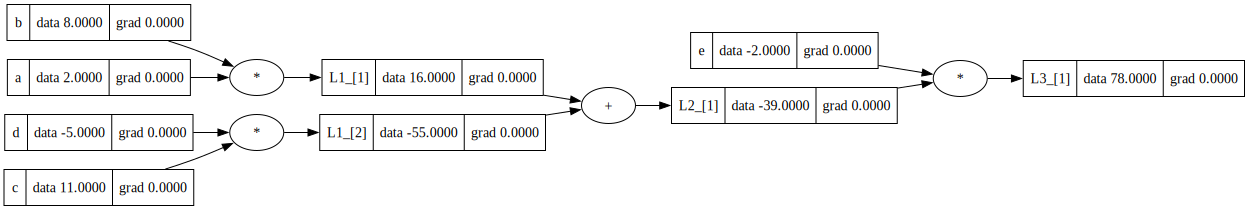

In [42]:
draw_dot(L3_1)